In [1]:
import pandas as pd
from db_utils import get_db_connection, fetch_data

# Create database connection
conn = get_db_connection()

# Fetch data into pandas dataframe
raw_data = fetch_data(conn, "SELECT data, value FROM macro_data WHERE id = 'rate_gs10'")
derived_data = fetch_data(conn, "SELECT data, value FROM macro_data WHERE id IN ('r_sp_earn', 'r_sp_price', 'r_sp_div')")

# Fetch average future real earnings (rolling 1200-month forward average)
future_earnings = fetch_data(
    conn,
    """
    SELECT 
        date,
        AVG(value) OVER (
            ORDER BY date
            ROWS BETWEEN 1 FOLLOWING AND 1200 FOLLOWING
        ) as value
    FROM derived.shiller_cape
    WHERE id = 'real_earn'
    ORDER BY date
    """
)


# Close connection
conn.close()

# Print first 5 rows
print(data.head())

ModuleNotFoundError: No module named 'db_utils'

In [52]:
# notebooks/predict_earnings.ipynb

import sys
import os
import pandas as pd

# Define the path to the directory containing 'db_utils'
# Adjust the relative path as necessary
current_dir = os.getcwd()
db_utils_path = os.path.join(current_dir, '..')  # Assuming 'db_utils' is one level up
db_utils_path = os.path.abspath(db_utils_path)

# Add 'db_utils' to sys.path if not already present
if db_utils_path not in sys.path:
    sys.path.insert(0, db_utils_path)

# Now, import the necessary functions
from db_utils import get_db_connection, fetch_data

# Create database connection
conn = get_db_connection()

# Fetch data into pandas dataframe
raw_data = fetch_data(conn, "SELECT date, id, value FROM macro_data WHERE id = 'rate_gs10'")
derived_data = fetch_data(conn, "SELECT date, id, value FROM shiller_derived_view WHERE id IN ('r_sp_earn', 'r_sp_price', 'r_sp_div')")

data = pd.concat([raw_data, derived_data], axis=0).set_index(['date', 'id'])['value'].unstack()

# Fetch average future real earnings (rolling 1200-month forward average)
future_earnings = fetch_data(
    conn,
    """
    SELECT 
        date,
        CASE
            WHEN COUNT(*) OVER (
                ORDER BY date 
                ROWS BETWEEN 1 FOLLOWING AND 120 FOLLOWING
            ) = 120 THEN
                AVG(value) OVER (
                    ORDER BY date
                    ROWS BETWEEN 1 FOLLOWING AND 120 FOLLOWING
                )
            ELSE NULL
        END as value
    FROM shiller_derived_view
    WHERE id = 'r_sp_earn'
    ORDER BY date
    """
).set_index('date').rename(columns={'value': 'future_earnings'})

# Close connection
conn.close()

# Print first 5 rows
print(data.head())

id          r_sp_div  r_sp_earn  r_sp_price  rate_gs10
date                                                  
1871-01-31  6.590422  10.139111  112.544132   5.320000
1871-02-28  6.395151   9.838694  110.685311   5.323333
1871-03-31  6.301772   9.695034  111.735271   5.326667
1871-04-30  6.540484  10.062284  119.238062   5.330000
1871-05-31  6.692577  10.296272  125.099702   5.333333


/workspaces/financial_db/db_utils/db_operations.py:75: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(
/workspaces/financial_db/db_utils/db_operations.py:75: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(


In [53]:
future_earnings

,future_earnings
date,
1871-01-31,11.289735
1871-02-28,11.341038
1871-03-31,11.392376
1871-04-30,11.438196
1871-05-31,11.482227
...,...
2024-05-31,NaN
2024-06-30,NaN
2024-07-31,NaN


In [54]:
y = future_earnings.div(data.loc(1)['r_sp_price'], axis=0).dropna()['future_earnings'].rename('rel_future_earnings')

<Axes: xlabel='date'>

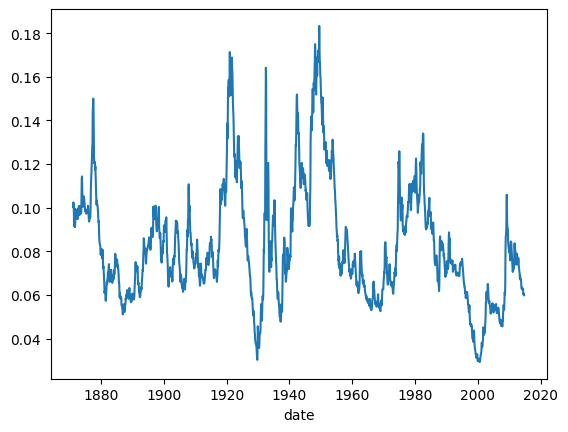

In [55]:
y.plot()

In [26]:
type(data.loc(1)['rate_gs10'])

pandas.core.series.Series